In [9]:
# Load the Sowutuom Clinic Dataset in Google Colab

from google.colab import files
import pandas as pd

print("📂 Please upload sowutuom_clinic_dataset.csv from your laptop")
uploaded = files.upload()   # This opens a file chooser

# Get the name of the uploaded file automatically
file_name = list(uploaded.keys())[0]
print("✅ Uploaded file:", file_name)

# Read the CSV into a DataFrame
df = pd.read_csv(file_name)

print("✅ Dataset loaded successfully! Preview:")
df.head()


📂 Please upload sowutuom_clinic_dataset.csv from your laptop


Saving sowutuom_clinic_dataset.csv to sowutuom_clinic_dataset (3).csv
✅ Uploaded file: sowutuom_clinic_dataset (3).csv
✅ Dataset loaded successfully! Preview:


,clinic,age,height,weight,bmi,glucose_level,blood_group,genotype,diabetic
0,clinic_1,18,168.9,91.3,31.7,116,O+,AA,0
1,clinic_1,60,170.8,87.9,29.8,76,B+,AA,0
2,clinic_1,55,182.2,77.9,23.2,102,O+,AA,0
3,clinic_1,21,177.0,69.4,22.3,92,O+,AS,0
4,clinic_1,75,164.6,51.4,19.2,105,O-,AA,0


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', None)
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


In [16]:
print("Shape:", df.shape)
print("\nColumn Names:", df.columns)
print("\nData Types:")
print(df.dtypes)

print("\nClass Distribution:")
print(df['diabetic'].value_counts())


Shape: (500, 9)

Column Names: Index(['clinic', 'age', 'height', 'weight', 'bmi', 'glucose_level',
       'blood_group', 'genotype', 'diabetic'],
      dtype='object')

Data Types:
clinic            object
age                int64
height           float64
weight           float64
bmi              float64
glucose_level      int64
blood_group       object
genotype          object
diabetic           int64
dtype: object

Class Distribution:
diabetic
0    430
1     70
Name: count, dtype: int64


In [17]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,age,height,weight,bmi,glucose_level,diabetic,clinic_clinic_2,clinic_clinic_3,clinic_clinic_4,clinic_clinic_5,blood_group_A-,blood_group_AB+,blood_group_B+,blood_group_B-,blood_group_O+,blood_group_O-,genotype_AS,genotype_SS
0,18,168.9,91.3,31.7,116,0,False,False,False,False,False,False,False,False,True,False,False,False
1,60,170.8,87.9,29.8,76,0,False,False,False,False,False,False,True,False,False,False,False,False
2,55,182.2,77.9,23.2,102,0,False,False,False,False,False,False,False,False,True,False,False,False
3,21,177.0,69.4,22.3,92,0,False,False,False,False,False,False,False,False,True,False,True,False
4,75,164.6,51.4,19.2,105,0,False,False,False,False,False,False,False,False,False,True,False,False


In [19]:
X = df_encoded.drop("diabetic", axis=1)
y = df_encoded["diabetic"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.shape, X_test.shape


((375, 17), (125, 17))

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train_scaled, y_train)
log_reg_pred = log_reg.predict(X_test_scaled)


In [22]:
print("🔹 Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, log_reg_pred))
print("Precision:", precision_score(y_test, log_reg_pred))
print("Recall:", recall_score(y_test, log_reg_pred))
print("F1 Score:", f1_score(y_test, log_reg_pred))

print("\nClassification Report:")
print(classification_report(y_test, log_reg_pred))


🔹 Logistic Regression Performance
Accuracy: 0.84
Precision: 0.25
Recall: 0.125
F1 Score: 0.16666666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       109
           1       0.25      0.12      0.17        16

    accuracy                           0.84       125
   macro avg       0.57      0.53      0.54       125
weighted avg       0.80      0.84      0.82       125



In [23]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [24]:
print("🔹 Random Forest Performance")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


🔹 Random Forest Performance
Accuracy: 0.872
Precision: 0.5
Recall: 0.1875
F1 Score: 0.2727272727272727

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       109
           1       0.50      0.19      0.27        16

    accuracy                           0.87       125
   macro avg       0.70      0.58      0.60       125
weighted avg       0.84      0.87      0.85       125



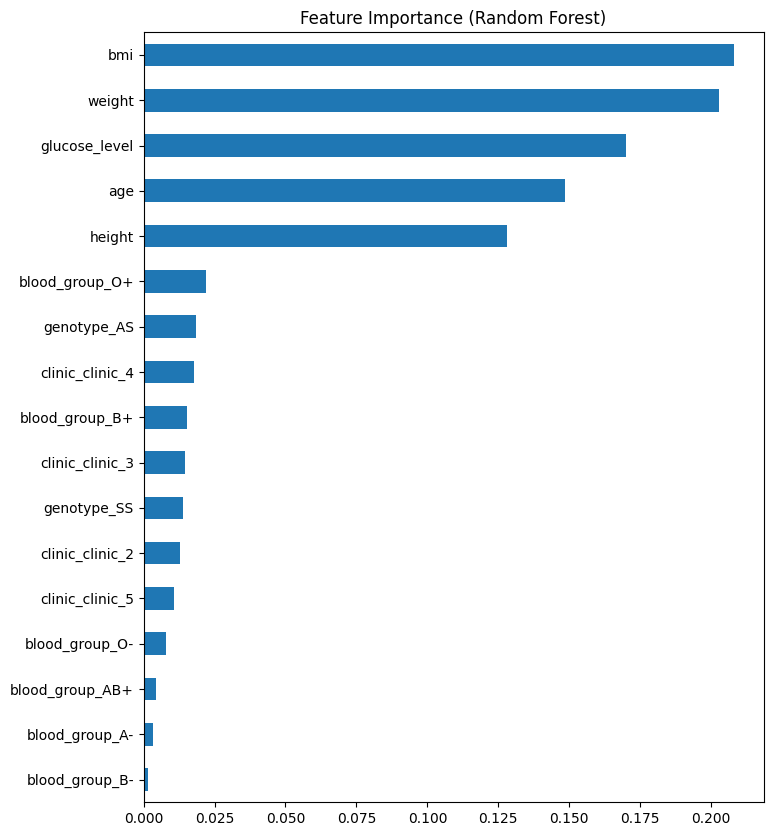

In [25]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind="barh", figsize=(8, 10))
plt.title("Feature Importance (Random Forest)")
plt.show()


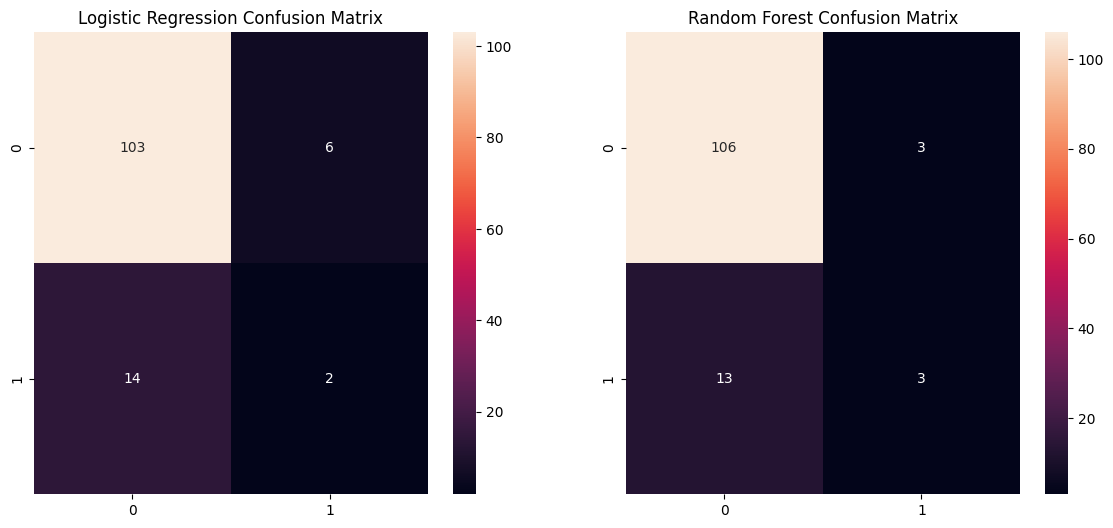

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))

sns.heatmap(confusion_matrix(y_test, log_reg_pred), annot=True, fmt='d', ax=ax[0])
ax[0].set_title("Logistic Regression Confusion Matrix")

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', ax=ax[1])
ax[1].set_title("Random Forest Confusion Matrix")

plt.show()


In [27]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_reg_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_reg_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_reg_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_reg_pred),
        f1_score(y_test, rf_pred)
    ]
})

results


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.840,0.25,0.1250,0.166667
1,Random Forest,0.872,0.50,0.1875,0.272727
